# Machine Learning - Part 1

By the end of this session, students should be able to:

1. Explain the difference between **rule-based systems** and **machine learning**
2. Distinguish between **supervised** and **unsupervised** learning
3. Distinguish between **regression** and **classification**
4. Identify **features (X)** and **target (y)** in a problem
5. Explain why we use **training** and **test** sets
6. Explain **data leakage** at a basic level
7. Build a first model in **scikit-learn**
8. Evaluate simple regression and classification models
9. Connect machine learning to business questions using a real dataset

In [6]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Plot style
sns.set_theme()


# From Rules to Machine Learning

## Rule-based thinking

Before machine learning, many business systems were rule-based.

A rule-based system uses explicit human-written logic, such as:

- If discount > 0.30, then flag as risky
- If order amount > 10,000, then send for review
- If customer has 3 failed payments, then suspend account

Rules are useful because they are:
- simple
- interpretable
- easy to explain

But rules can also be limited because:
- they are rigid
- they do not adapt well
- they may miss complex patterns

Let's create a tiny example.


In [7]:
# Tiny example: a simple rule-based decision
toy_df = pd.DataFrame({
    "discount": [0.05, 0.10, 0.20, 0.35, 0.40, 0.50],
    "sales":    [100, 120, 150, 200, 220, 260],
    "profit":   [25, 20, 10, -5, -15, -30]
})

# Rule: flag an order as risky if discount > 0.30
toy_df["rule_pred_loss"] = (toy_df["discount"] > 0.30).astype(int)

# Actual loss label: 1 if profit is negative, else 0
toy_df["actual_loss"] = (toy_df["profit"] < 0).astype(int)

toy_df


,discount,sales,profit,rule_pred_loss,actual_loss
0,0.050,100,25,0,0
1,0.100,120,20,0,0
2,0.200,150,10,0,0
3,0.350,200,-5,1,1
4,0.400,220,-15,1,1
5,0.500,260,-30,1,1


### Discussion

The rule above is easy to understand:
- if discount is high, predict loss

But what if:
- some high-discount orders are still profitable?
- sales volume also matters?
- category matters?
- region matters?
- the relationship is not simple?

This is where machine learning becomes useful.


## Machine learning thinking

Machine learning does not rely only on manually written rules.

Instead, it:
- looks at historical data
- learns patterns from examples
- uses those learned patterns to make predictions

In plain English:

> A rule-based system says:  
> **"I will tell the computer the rule."**

> A machine learning system says:  
> **"I will give the computer examples, and it will learn the pattern."**

That does **not** mean ML is magic.  
It still depends on:
- data quality
- problem framing
- feature choice
- evaluation


## When should we use rules vs ML?

### Rule-based approaches are often good when:
- logic is simple
- rules are stable
- interpretability is critical
- data is limited

### ML is often good when:
- relationships are more complex
- many variables matter together
- we have enough historical examples
- we want prediction, not just manual logic

---

## Quick comparison

| Question | Rules | Machine Learning |
|---|---:|---:|
| Easy to explain? | Yes | Sometimes |
| Flexible? | Limited | More flexible |
| Learns from data? | No | Yes |
| Needs training data? | No | Yes |
| Good for complex patterns? | Limited | Often yes |


# Main Types of Machine Learning

At a high level, we can divide machine learning into a few major categories.

The two most important for this course are:

1. **Supervised learning**
2. **Unsupervised learning**


## Supervised learning

In supervised learning, we have:
- **inputs** (features)
- **answers** (target / label)

The model learns from examples where the correct answer is already known.

### Examples
- Predict house price
- Predict customer churn
- Predict whether an order will lose money
- Predict sales next month

If we already know the outcome in historical data, that is a supervised learning setup.


## Unsupervised learning

In unsupervised learning, we do **not** provide the correct answer.

Instead, we ask the algorithm to find structure in the data.

### Examples
- Group customers into segments
- Find unusual patterns
- Reduce dimensions for visualization
- Discover hidden clusters

A common unsupervised method is **clustering**.


In [9]:
# Create a small dataset with 2 features (x and y)
cluster_df = pd.DataFrame({
    "x": [1, 1.5, 2, 8, 8.5, 9],      # feature 1
    "y": [1, 1.2, 0.8, 8, 8.3, 8.8]   # feature 2
})

# Initialize KMeans model with 2 clusters
kmeans = KMeans(
    n_clusters=2,     # number of clusters to find
    random_state=42,  # for reproducibility
    n_init=10         # number of times to run algorithm
)

# Fit the model and assign cluster labels to each row
cluster_df["cluster"] = kmeans.fit_predict(cluster_df[["x", "y"]])

# Display the result
cluster_df


,x,y,cluster
0,1.000,1.000,0
1,1.500,1.200,0
2,2.000,0.800,0
3,8.000,8.000,1
4,8.500,8.300,1
5,9.000,8.800,1


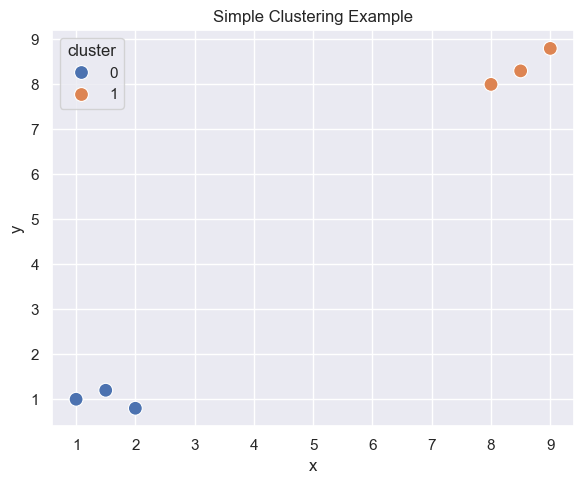

In [10]:
# Plot the clustering result
plt.figure(figsize=(6, 5))  # set figure size

sns.scatterplot(
    data=cluster_df,
    x="x",           # x-axis: feature x
    y="y",           # y-axis: feature y
    hue="cluster",   # color points by assigned cluster
    s=100            # marker size
)

plt.title("Simple Clustering Example")  # chart title
plt.tight_layout()  # adjust spacing
plt.show()          # display plot

### Key point

In the clustering example above:
- we did **not** tell the model the correct labels
- the algorithm grouped similar points on its own

That is unsupervised learning.

For the rest of this module, our focus will be on **supervised learning**.


# Framing Supervised ML Problems

This is the most important conceptual section of the session.

A supervised learning problem usually has:
- **features (X)** = inputs we use to predict
- **target (y)** = output we want to predict

We also need to decide whether the problem is:
- **regression**
- **classification**


## Features (X) vs target (y)

### Features (X)
Features are the input variables.

Examples:
- sales
- discount
- quantity
- region
- category
- customer segment

### Target (y)
The target is what we want to predict.

Examples:
- profit
- whether an order is profitable
- whether a customer will churn
- future sales

---

## Important habit

Before you write ML code, always ask:

1. What exactly am I predicting?
2. What information am I allowed to use to predict it?


In [11]:
# Create a small example dataset
tiny_orders = pd.DataFrame({
    "sales": [120, 200, 150, 300],     # sales amount
    "discount": [0.10, 0.30, 0.05, 0.40],  # discount level
    "profit": [15, -10, 20, -25]       # profit (can be negative)
})

# Example 1: regression problem (predict a number)
X_reg = tiny_orders[["sales", "discount"]]  # features (inputs)
y_reg = tiny_orders["profit"]               # target (output: numeric)

# Example 2: classification problem (predict a label)
X_clf = tiny_orders[["sales", "discount"]]          # same features
y_clf = (tiny_orders["profit"] < 0).astype(int)     # 1 = loss, 0 = not loss

# Print results
print("Regression features (X):")
print(X_reg)

print()  # blank line

print("Regression target (y):")
print(y_reg)

print()  # blank line

print("Classification target (y):")
print(y_clf)

Regression features (X):
   sales  discount
0    120     0.100
1    200     0.300
2    150     0.050
3    300     0.400

Regression target (y):
0    15
1   -10
2    20
3   -25
Name: profit, dtype: int64

Classification target (y):
0    0
1    1
2    0
3    1
Name: profit, dtype: int64


## Regression

Use **regression** when the target is a numeric value.

### Examples
- Predict profit
- Predict revenue
- Predict temperature
- Predict house price

Regression answers questions like:
> "How much?"  
> "What value?"


## Classification

Use **classification** when the target is a category or label.

### Examples
- Predict whether an order will lose money
- Predict spam vs not spam
- Predict churn vs not churn
- Predict fraud vs not fraud

Classification answers questions like:
> "Which class?"  
> "Yes or no?"


## Same dataset, two different ML problems

This is a powerful idea:

The **same dataset** can support multiple ML problems depending on how we define the target.

### Example with retail data:
- **Regression target:** predict `Profit`
- **Classification target:** predict `Loss` where `Loss = 1 if Profit < 0 else 0`

That means ML starts with **problem framing**, not with choosing a model.


# Meet scikit-learn

## What is scikit-learn?

**scikit-learn** (usually imported as `sklearn`) is one of the most popular Python libraries for machine learning.

It provides:
- models
- preprocessing tools
- train/test splitting
- evaluation metrics
- pipelines
- clustering tools

It is one of the best libraries for learning core ML ideas.


## A typical scikit-learn workflow

Many sklearn models follow the same pattern:

```python
model = SomeModel()
model.fit(X_train, y_train)
pred = model.predict(X_test)
```

This consistency is one reason sklearn is so useful for teaching.


In [12]:
# Minimal scikit-learn workflow on tiny data
X = tiny_orders[["sales", "discount"]]
y = tiny_orders["profit"]

simple_model = LinearRegression()
simple_model.fit(X, y)

simple_pred = simple_model.predict(X)
simple_pred


array([ 15.20661157, -10.18595041,  19.87603306, -24.89669421])

### Vocabulary

- `fit()` = learn from data
- `predict()` = make predictions
- `score()` = quick built-in performance measure for some models

Today, we will use:
- `LinearRegression()` for regression
- `LogisticRegression()` for classification


# Real Dataset: Retail Orders

We now move from tiny examples to a real business dataset.

We will use the **Sample Superstore** retail dataset, which includes:
- product category
- sub-category
- sales
- profit
- discount
- region
- order date
- customer segment

This is a great dataset because it supports both:
- descriptive analysis
- predictive modeling


In [13]:
# Load the Superstore dataset
data_url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"
df = pd.read_csv(data_url, encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.000",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.000,0.000,41.914
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.000",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.000,0.000,219.582
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.000",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.000,0.000,6.871
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.000",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.577,5.000,0.450,-383.031
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.000",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.000,0.200,2.516


In [14]:
# Basic dataset info
print("Shape:", df.shape)
print()
print(df.dtypes)


Shape: (10800, 21)

Row ID               str
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object


In [15]:
# Convert columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])  # order date
df["Ship Date"] = pd.to_datetime(df["Ship Date"])    # shipping date

# Create time-based features
df["Order Year"] = df["Order Date"].dt.year    # extract year
df["Order Month"] = df["Order Date"].dt.month  # extract month

# Calculate shipping delay in days
df["Ship Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Create classification target: 1 = loss, 0 = not loss
df["Loss"] = (df["Profit"] < 0).astype(int)

df.head()  # view first few rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Ship Delay,Loss
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.000",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.000,0.000,41.914,2017,11,3,0
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.000",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.000,0.000,219.582,2017,11,3,0
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.000",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.000,0.000,6.871,2017,6,4,0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.000",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.577,5.000,0.450,-383.031,2016,10,7,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.000",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.000,0.200,2.516,2016,10,7,0


## Quick business intuition

Each row is an order line.

That means we could ask supervised learning questions like:

### Regression question
> Can we predict **Profit** from sales, discount, quantity, shipping, and category information?

### Classification question
> Can we predict whether an order is **loss-making**?

These are realistic examples because businesses often care about:
- profitability
- risk
- pricing
- discount strategy


In [16]:
# Quick look at core numeric columns
df[["Sales", "Quantity", "Discount", "Profit", "Ship Delay", "Loss"]].describe()

,Sales,Quantity,Discount,Profit,Ship Delay,Loss
count,"9,994.000","9,994.000","9,994.000","9,994.000","9,994.000","10,800.000"
mean,229.858,3.790,0.156,28.657,3.958,0.173
std,623.245,2.225,0.206,234.260,1.748,0.378
min,0.444,1.000,0.000,"-6,599.978",0.000,0.000
25%,17.280,2.000,0.000,1.729,3.000,0.000
50%,54.490,3.000,0.200,8.666,4.000,0.000
75%,209.940,5.000,0.200,29.364,5.000,0.000
max,"22,638.480",14.000,0.800,"8,399.976",7.000,1.000


In [17]:
# Check class balance for the classification problem
df["Loss"].value_counts(normalize=True).rename("proportion")


Loss
0   0.827
1   0.173
Name: proportion, dtype: float64

### Discussion

If the `Loss` class is much smaller or much larger than the non-loss class, that affects:
- baseline performance
- model evaluation
- interpretation of accuracy

This is one reason why problem framing and evaluation matter.


##  A quick visual bridge from visualization to ML

Before modeling, it is still useful to look at patterns visually.

This reinforces a key course message:

> Good machine learning starts with understanding the data.


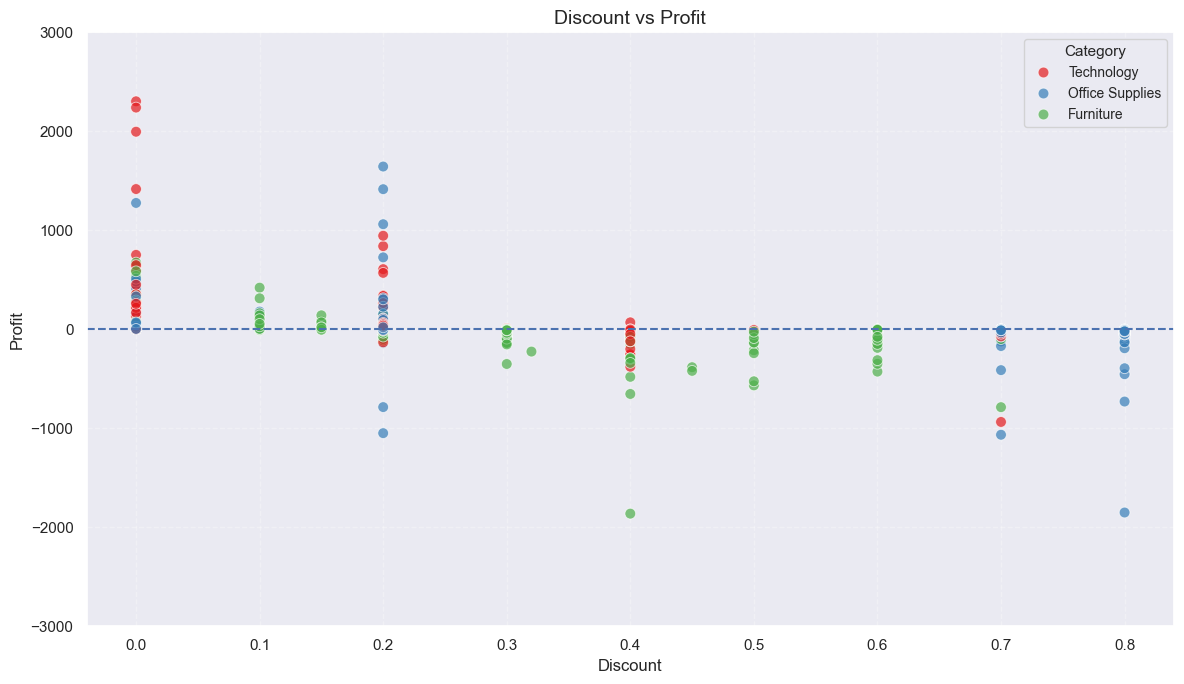

In [20]:
# Take a sample (same as before)
sample_vis = df.sample(2000, random_state=42)

# Create a clearer scatter plot
plt.figure(figsize=(12, 7))  # larger figure

sns.scatterplot(
    data=sample_vis,
    x="Discount",
    y="Profit",
    hue="Category",
    palette="Set1",     # stronger, more distinct colors
    alpha=0.7,          # slightly less transparent
    s=60                # bigger dots
)

# Add horizontal line at profit = 0
plt.axhline(0, linestyle="--", linewidth=1.5)

# Improve labels and title
plt.title("Discount vs Profit", fontsize=14)
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit", fontsize=12)

# Improve legend
plt.legend(title="Category", fontsize=10, title_fontsize=11)

# Optional: limit extreme outliers (makes pattern clearer)
plt.ylim(-3000, 3000)

# Add grid for readability
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Reflection

This plot does **not** prove causation, but it can guide our thinking.

Questions to ask:
- Do higher discounts often appear with lower profit?
- Do categories behave differently?
- Would these variables be useful as ML features?


# Regression Example: Predict Profit

We will now build our first regression model.

## Problem framing

### Goal
Predict the numeric value of **Profit**

### Target
`Profit`

### Candidate features
We will start simple and use only numeric features:
- `Sales`
- `Quantity`
- `Discount`
- `Ship Delay`

We start simple on purpose:
- fewer concepts at once
- easy to inspect
- good for beginners

Later in the course, we will add:
- categorical variables
- encoding
- scaling
- pipelines


In [47]:
# Select features (X) and target (y) for regression
reg_features = ["Sales", "Quantity", "Discount", "Ship Delay"]
X_reg = df[reg_features]
y_reg = df["Profit"]

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)


X_reg shape: (9983, 4)
y_reg shape: (9983,)


## Train/test split

We do **not** train and evaluate on the exact same data.

Instead, we split the data into:
- **training set** = data the model learns from
- **test set** = data used for final evaluation

This helps answer the real question:

> How well does the model perform on unseen data?


In [26]:
# Drop missing values
clean_df = df[reg_features + ["Profit"]].dropna()

# Recreate X and y
X_reg = clean_df[reg_features]
y_reg = clean_df["Profit"]

In [58]:
# Split data into training and test sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,          # features and target
    test_size=0.20,        # 20% for testing, 80% for training
    random_state=42        # fixed seed for reproducibility
)

# Check sizes of the splits
print("Training set size:", X_reg_train.shape)  # training data (used to learn)
print("Test set size:", X_reg_test.shape)       # test data (used to evaluate)

Training set size: (7986, 4)
Test set size: (1997, 4)


## Train the regression model

We start with **Linear Regression** because it is:
- simple
- classic
- easy to interpret at a high level
- a strong baseline model


In [56]:
# Create a linear regression model
reg_model = LinearRegression()  # initialize model

# Train (fit) the model using training data
reg_model.fit(
    X_reg_train,  # input features
    y_reg_train   # target values
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
# Make predictions on the test set
reg_pred = reg_model.predict(X_reg_test)

# View first few predictions
pd.DataFrame({
    "actual_profit": y_reg_test.head(10).values,
    "predicted_profit": reg_pred[:10]
})


,actual_profit,predicted_profit
0,-8.379,-61.014
1,12.246,49.355
2,-9.264,-138.013
3,65.435,70.616
4,726.562,355.287
5,3.294,-20.722
6,123.474,166.403
7,3.110,30.581
8,16.249,37.716
9,123.455,89.145


## Evaluate regression performance

Common regression metrics include:

- **MAE** = Mean Absolute Error  
  Average absolute prediction error

- **RMSE** = Root Mean Squared Error  
  Like MAE, but penalizes larger errors more heavily

- **R²** = proportion of variance explained  
  Higher is generally better


In [70]:
# Regression evaluation metrics
reg_mae = mean_absolute_error(y_reg_test, reg_pred)
reg_rmse = np.sqrt(mean_squared_error(y_reg_test, reg_pred))
reg_r2 = r2_score(y_reg_test, reg_pred)

print("MAE :", reg_mae)
print("RMSE:", reg_rmse)
print("R^2 :", reg_r2)


MAE : 60.5149683267243
RMSE: 211.17025592369703
R^2 : 0.27662294955035027


### Interpretation prompt

Do not ask only:
> "Is R² high?"

Also ask:
- Is the prediction error small enough to be useful?
- Would this model support a business decision?
- Are we using enough relevant features?
- Might a simple linear model miss non-linear patterns?


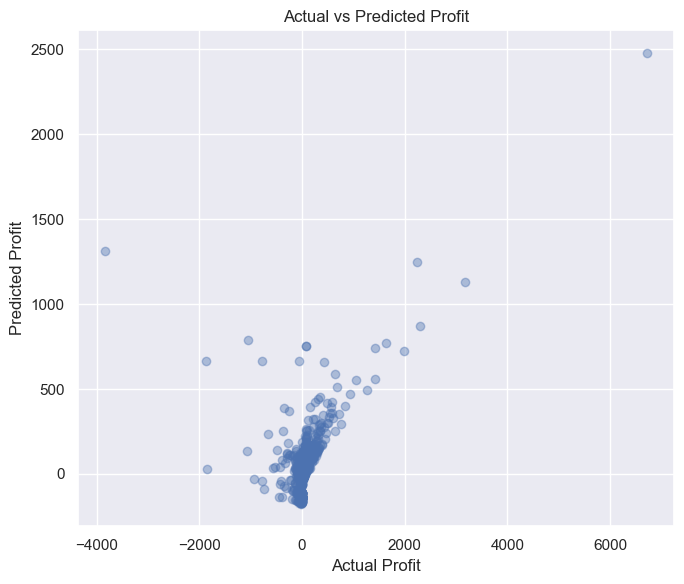

In [71]:
# Plot actual vs predicted profit
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, reg_pred, alpha=0.4)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.tight_layout()
plt.show()


### What would a good plot look like?

If predictions were perfect, all points would lie on a clean diagonal.

In practice:
- some spread is expected
- large scatter means the model is not capturing the relationship well

This is a good moment to remind students:
> first models are often baseline models, not final models


# Classification Example: Predict Loss

Now we reframe the same dataset as a classification problem.

## Problem framing

### Goal
Predict whether an order will lose money

### Target
`Loss`
- `1` = loss-making order
- `0` = not loss-making order

### Features
To keep comparison simple, we will start with the same numeric features:
- `Sales`
- `Quantity`
- `Discount`
- `Ship Delay`


In [73]:
# Select features (inputs) and target (output) for classification
clf_features = ["Sales", "Quantity", "Discount", "Ship Delay"]  # input variables
X_clf = df[clf_features]  # feature matrix (X)
y_clf = df["Loss"]        # target variable (1 = loss, 0 = not loss)

# Check how common loss cases are
print("Loss rate:", y_clf.mean())  # mean of 0/1 → proportion of loss cases

Loss rate: 0.18741861163978765


In [74]:
# Split data into training and test sets for classification
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf,          # features and target
    test_size=0.20,        # 20% test, 80% training
    random_state=42,       # reproducibility
    stratify=y_clf         # keep same class balance (loss vs not loss)
)

# Check sizes of the splits
print("Training set size:", X_clf_train.shape)  # training data
print("Test set size:", X_clf_test.shape)       # test data

Training set size: (7986, 4)
Test set size: (1997, 4)


## Train the classification model

We start with **Logistic Regression**, which is a standard baseline for binary classification.

Despite the name "regression", Logistic Regression is mainly used for **classification**.


In [75]:
# Train logistic regression
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_clf_train, y_clf_train)

# Predict labels on the test set
clf_pred = clf_model.predict(X_clf_test)
clf_pred[:10]


array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

## 7.2 Evaluate classification performance

Common classification metrics:

- **Accuracy** = how often predictions are correct
- **Precision** = when we predict loss, how often are we right?
- **Recall** = how many real loss cases did we catch?
- **F1** = balance between precision and recall

Important:

> Accuracy alone is often not enough.


In [ ]:
# Classification evaluation metrics
clf_accuracy = accuracy_score(y_clf_test, clf_pred)
clf_precision = precision_score(y_clf_test, clf_pred)
clf_recall = recall_score(y_clf_test, clf_pred)
clf_f1 = f1_score(y_clf_test, clf_pred)

print("Accuracy :", clf_accuracy)
print("Precision:", clf_precision)
print("Recall   :", clf_recall)
print("F1       :", clf_f1)


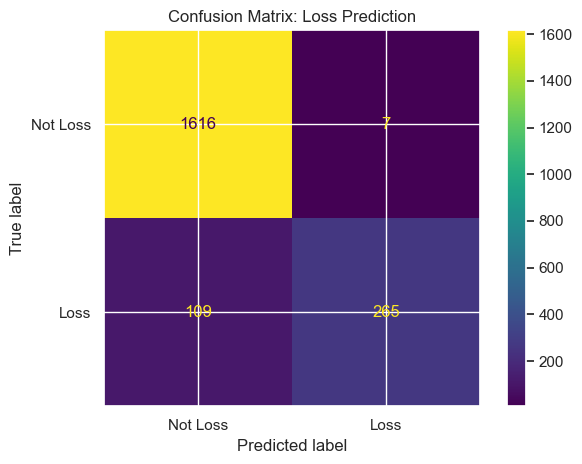

In [76]:
# Confusion matrix
cm = confusion_matrix(y_clf_test, clf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Loss", "Loss"])
disp.plot()
plt.title("Confusion Matrix: Loss Prediction")
plt.tight_layout()
plt.show()


### Discussion

Suppose this were used by a pricing manager.

Which is worse?
- predicting a loss when the order would actually be fine?
- missing a real loss-making order?

The answer depends on business context.

This is why classification is not just a coding task.  
It is also a **decision problem**.


# Same Data, Different Problem Framing

This is one of the biggest lessons in introductory ML.

With the same dataset:

### Regression version
- Target = `Profit`
- Ask: **How much profit will we make?**

### Classification version
- Target = `Loss`
- Ask: **Will we lose money or not?**

These are different ML problems with:
- different targets
- different evaluation metrics
- different decisions

So before choosing a model, always choose the **business question**.


#  Why Training vs Test Split Matters

## Why not evaluate on the same data we trained on?

Because the model has already seen that data.

A model can look very good on familiar data, but weaker on new data.

The test set gives us a more honest estimate of real-world performance.


In [ ]:
# Compare training vs test performance for regression
reg_train_pred = reg_model.predict(X_reg_train)

train_r2 = r2_score(y_reg_train, reg_train_pred)
test_r2 = r2_score(y_reg_test, reg_pred)

print("Training R^2:", train_r2)
print("Test R^2    :", test_r2)


### Interpretation

If training performance is much better than test performance, that can be a warning sign.

It may suggest:
- overfitting
- unstable patterns
- not enough useful features
- a mismatch between model and data


## Early introduction to data leakage

**Data leakage** means the model gets access to information it should not fairly have at prediction time.

This leads to unrealistic performance.

### Leakage examples
- using the target itself as a feature
- using future information
- preprocessing the full dataset before splitting
- including variables created from information not available at prediction time

Leakage makes a model look better than it really is.


In [ ]:
# BAD example: using the target itself as a feature
bad_features = ["Sales", "Quantity", "Discount", "Profit"]  # Profit should not be used to predict Loss
X_bad = df[bad_features]
y_bad = df["Loss"]

X_bad_train, X_bad_test, y_bad_train, y_bad_test = train_test_split(
    X_bad, y_bad, test_size=0.20, random_state=42, stratify=y_bad
)

bad_model = LogisticRegression(max_iter=1000)
bad_model.fit(X_bad_train, y_bad_train)
bad_pred = bad_model.predict(X_bad_test)

print("Accuracy with leakage:", accuracy_score(y_bad_test, bad_pred))


### Why is the example above bad?

Because `Loss` is defined directly from `Profit`.

So if we include `Profit` as a feature while predicting `Loss`, the model is effectively seeing the answer.

That is not real prediction.  
That is leakage.

---

## Practical habit

Before training a model, ask:

> "Would this information truly be available at the moment I want to make the prediction?"

If the answer is no, do not use it.


# Scikit-learn Mental Model

By now, you have seen the basic sklearn pattern several times.

## Core steps

```python
X = ...
y = ...

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SomeModel()
model.fit(X_train, y_train)

pred = model.predict(X_test)
```

This pattern will appear again and again in this course.

Later we will add:
- preprocessing
- encoding
- scaling
- pipelines
- cross-validation
- more advanced models


# Guided Practice

Use the cells below as in-class exercises.

The goal is not just to run code.  
The goal is to think clearly about the ML problem.


## Exercise 1. Problem framing

For each question below, decide whether it is:
- regression
- classification
- supervised or unsupervised

1. Predict the exact sales value for an order  
2. Predict whether a customer will churn  
3. Group stores into similar clusters  
4. Predict whether an order will be profitable  
5. Predict annual revenue


## Exercise 2. Features vs target

Using the retail dataset, identify:
- one possible regression target
- one possible classification target
- at least four possible features

Write your answers in a markdown cell below.


In [ ]:
# Your notes for Exercise 2


## Exercise 3. Build your own regression version

Try a different set of features for predicting `Profit`.

Ideas:
- add `Order Month`
- add `Order Year`
- compare performance
- ask whether the model improves


In [ ]:
# Exercise 3 workspace
# Example starter:
# my_features = ["Sales", "Quantity", "Discount", "Ship Delay", "Order Month", "Order Year"]


## Exercise 4. Build your own classification version

Try predicting `Loss` again, but:
- use a different train/test split random state
- compare metrics
- ask whether accuracy changes much


In [ ]:
# Exercise 4 workspace


## Exercise 5. Leakage check

For each variable below, discuss whether it is safe to use when predicting `Loss` **before** the order is finalized:

- Sales  
- Discount  
- Profit  
- Ship Delay  
- Category  
- Region  

Which variables might create leakage?


In [ ]:
# Your notes for Exercise 5
